# **Population-Scale Homeostatic Simulations**

# **Yu Model — Heterogeneous Population (200 neurons)**

This notebook investigates homeostatic compensatory mechanisms 
in a heterogeneous population of 200 dopaminergic neurons 
following targeted pharmacological blockades.

**Simulation protocol :**
- Baseline phase : 0 → 30 s
- Blockade applied instantaneously at t = 30 s
- Compensation observed until t = 300 s

**Blockades simulated :**
1. L-type calcium channels (Cav1.3) — isradipine strategy
2. HCN channels — validation (should preserve pacemaking)
3. A-type potassium channels — validation (should preserve pacemaking)


# **Useful packages and functions**

In [1]:
using DifferentialEquations, Plots, Plots.PlotMeasures, LaTeXStrings, Random, Dierckx, DelimitedFiles
using Interpolations
using OrdinaryDiffEq
using NmodController
include("DA_kinetics2.jl") 
include("Essaie2.jl")
include("STG_utils2.jl")

extract_burstiness (generic function with 1 method)

# **Global variables**

In [2]:
Tfinal = 3000000
tspan  = (0.0, Tfinal)

tt = 0. : 0.01 : Tfinal
tt_rand = 0. : 1 : Tfinal
ncells = 200

gr(guidefontsize=18, legendfontsize=12, margin=5Plots.mm, grid=false)
myApple = RGBA(187/255, 206/255, 131/255, 1)
mySalmon = RGBA(243/255, 124/255, 130/255)
myYellow = RGBA(228/255, 205/255, 121/255, 1)
myBlue = RGBA(131/255, 174/255, 218/255, 1)
myDarkBlue = RGBA(114/255, 119/255, 217/255, 1)
myOrange = RGBA(241/255, 175/255, 113/255, 1)
myPink = RGBA(243/255, 124/255, 130/255, 1)
myPurple = RGBA(169/255, 90/255, 179/255, 1)
myGreen = RGBA(132/255, 195/255, 168/255, 1)
myRed = RGBA(158/255, 3/255, 8/255, 1)
myGray = RGBA(150/255, 150/255, 150/255, 1)
myLightBlue = RGBA(127/255, 154/255, 209/255, 1)
default(fmt = :png)

moving_average(vs, n, padding) = [sum(vs[i:(i+n-1)])/n for i in 1:padding:(length(vs)-(n-1))];

In [3]:
# Definition of reversal potential values (in mV), [Mg] and membrane capacitance
const VNa     = 60. # Sodium reversal potential
const VK      = -90. # Potassium reversal potential
const VCa     = 50. # Calcium reversal potential
const VH      = -29. # H reversal potential
const VLNS    = -65. # Leak reversal potential
const EPacemaker = 4.2732015978991615 # Reversal potential of pacemaking channels

const C       = 1. # Membrane capacitance
const fCa     = 0.018 # Fraction of unbuffered free calcium
const ICapmax = 11 # Maximum calcium pump current
const F       = 96520 # Faraday constant in ms*µA/mmol (and taking cm³=mL)
const d       = 15 # Soma diameter in cm
const L       = 25 # Soma length

# Definition of voltage range for the DICs
const Vmin = -100 
const Vmax = 50
const Vrange = range(Vmin, stop=Vmax, step=0.0154640);

# **Population Setup and Calibration**

The 200-neuron population was pre-generated by Fyon et al.via random sampling in conductance space, retaining only neurons 
with pacemaking activity (1–5 Hz).

In [5]:
# 2. Chargement des conductances pré-calculées
g_all_init = readdlm("g_all.dat", '\t', Float64)

# Vérification : on s'assure qu'on a bien nos 200 neurones
ncells = size(g_all_init, 1) 
println("Chargement réussi : $(ncells) neurones prêts.")

Chargement réussi : 200 neurones prêts.


# **Calibration of gCaT (T-type conductance)**

For each neuron, gCaT is calibrated so that T-type channels 
contribute exactly 10% of the total calcium influx per 
pacemaking cycle. This ensures a meaningful alternative 
calcium source when L-type channels are blocked.

In [4]:
#Definition de la fonction qui va permettre de définir la valeur de conductance de gTtype 
# L'idée est de s'assurer que quand on bloque gCaL, le point de départ 
#du T-type est déjà suffisamment significatif pour que la compensation homéostatique reste dans une gamme raisonnable

function calibrate_gTtype(sol, p_init; target_ratio=0.1)
    # 1. Détection des spikes pour isoler un cycle
    gCaL = p_init[3]
    gCaT_fallback = 0.1 * gCaL
    threshold = gCaT_fallback
    v_trace = sol[1, :]
    times = sol.t
    spike_indices = findall(i -> v_trace[i-1] < 0 && v_trace[i] >= 0, 2:length(v_trace))
    
    if length(spike_indices) < 2
        return 0.2 
    end
    
    idx1, idx2 = spike_indices[end-1], spike_indices[end]
    tt = range(times[idx1], times[idx2], length=1000)
    res = sol(tt)
    V = res[1, :]
    dt = tt[2] - tt[1]
    
    gCaL   = p_init[3]
    gLCa   = p_init[10]
    gNtype = p_init[12]
    
    # Calculer les intégrales des courants 
    # Q = g * ∫ (gating * (V-VCa)) dt
    # On calcule A = ∫ (gating * (V-VCa)) dt

    # 1. L-type 
    l = res[5, :]
    A_CaL = sum(l .* (V .- VCa)) * dt
    
    # 2. N-type 
    mN = res[14, :]
    hN = res[15, :]
    A_CaN = sum((mN .^ 2) .* hN .* (V .- VCa)) * dt
    
    # 3. Fuite Ca
    A_LCa = sum(V .- VCa) * dt
    
    # 4. T-type 
    mT = res[16, :]
    hT = res[17, :]
    A_CaT = sum(mT .* hT .* (V .- VCa)) * dt
    
    # Équation de calibration :
    # gT * A_CaT / (gCaL * A_CaL + gLCa * A_LCa + gT * A_CaT + gN * A_CaN) = target_ratio
    num = target_ratio * (gCaL * A_CaL + gNtype * A_CaN + gLCa * A_LCa)
    
    den = A_CaT * (1 - target_ratio)
    
    gT_calibrated = abs(num / den)
    print(gT_calibrated)
    return gT_calibrated
end
    



calibrate_gTtype (generic function with 1 method)

In [6]:
ncells = 200
gTtype_final=zeros(ncells)

@showprogress "Computing Population..." for i = 1 : ncells
    # 1. Initialisation classique des paramètres
    gNa = g_all_init[i,1]
    gCaL = g_all_init[i,2]
    gKd = g_all_init[i,3]
    gKA = g_all_init[i,4]
    gKERG = g_all_init[i,5]
    gKSK = g_all_init[i,6]
    gH = g_all_init[i,7]
    gLNS = g_all_init[i,8]
    gLCa = g_all_init[i,9]
    gNtype = 0.2*(0.9 + 0.2 * rand()) 
    gTtype = 0.025 
    
    Iapp(t) = 0 
    p_calib = (Iapp, gNa, gCaL, gKd, gKA, gKERG, gKSK, gH, gLNS, gLCa, gNtype, gTtype)
    V0 = -50.
    Ca0 = 1e-4
    x0 = [V0, m_inf(V0), h_inf(V0), hs_inf(V0), l_inf(V0), n_inf(V0), p_inf(V0), q1_inf(V0), q2_inf(V0), 
         0., 0., mH_inf(V0), Ca0, mN_inf(V0), hN_inf(V0), mT_inf(V0), hT_inf(V0)]
    tspan_calib = (0.0, 1000.0)
    prob_calib = ODEProblem(DA_ODE, x0, tspan_calib, p_calib) 
    sol_calib = solve(prob_calib,maxiters=1e6)
    gTtype_final[i] = calibrate_gTtype(sol_calib, p_calib; target_ratio=0.1)
   
    
end



0.37181950796285020.38239043301250875

Computing Population...   1%|█                           |  ETA: 0:52:09

0.163206926035028430.182415006404265220.46849440650364011.07186148153893450.59866681969240480.85162523061784620.28091528596614570.61904186561942730.099436679642229960.149883700370121470.71228011661164280.288963956951955040.37331798954250670.38786478903456140.123160197792262730.4486191621737550.60763788844122360.65866348865967060.57668949978892610.5739679436460790.50048371575680440.53105795362571870.223318031438824340.34340737097974180.091675623224558440.6385056791008470.38977413783065370.57911932601569570.45309802280532611.16905246708437850.257256904596607550.339172811838461260.70214378539326580.47130630602872110.48368663091413440.5573361264291960.28421921384080680.09186887081472141.11202748352612770.47372506246273190.29117682998150981.28201285527456290.26152051730341040.9903950136626310.97180977066563410.41569667018228980.12619908371251950.135610522299816850.44831113904106480.62160281779051780.43682767343683930.52069576501975670.43924317384224860.67962501638398710.458679846499345730.3

Computing Population...  58%|█████████████████           |  ETA: 0:00:25

0.58627346168203220.39260138258061820.097313759704814230.241352052491745320.31841134045193070.048998408201929090.55211878686623310.31380336908254390.39991953808919930.177001867225876460.356195372891135730.4052920146538520.125943225120442480.25273924640602110.37727116743610280.5034412591858951

...

Computing Population...  94%|███████████████████████████ |  ETA: 0:00:02

0.133893328306031430.154239848761324540.562566009050072

Computing Population...  99%|████████████████████████████|  ETA: 0:00:00

1.35288930539728370.083500162858460990.5592840099168667

Computing Population... 100%|████████████████████████████| Time: 0:00:36


# **Calibration of individual calcium targets (Ca_tgt)**

Each neuron has a unique resting calcium concentration depending on its initial conductance profile. Ca_tgt is 
defined as the mean [Ca²⁺] during a free-running simulation (no homeostatic controller, no blockade).

In [7]:
ncells= 200
Tfinal = 100000
tt = 0.0 : 0.2 : Tfinal
tspan  = (0.0, Tfinal)
freqs_pre = zeros(ncells)
win_pre   = (5000, 25000)

Ca_tgt_moyen =zeros(ncells)

@showprogress "Computing Population..." for i = 1 : ncells
    gNa = g_all_init[i,1]
    gCaL = g_all_init[i,2]
    gKd = g_all_init[i,3]
    gKA = g_all_init[i,4]
    gKERG = g_all_init[i,5]
    gKSK = g_all_init[i,6]
    gH = g_all_init[i,7]
    gLNS = g_all_init[i,8]
    gLCa = g_all_init[i,9]
    gNtype = 0.2*(0.9 + 0.2 * rand()) 
    gTtype = gTtype_final[i]
    
    Iapp(t) = 0 
    p = (Iapp, gNa, gCaL, gKd, gKA, gKERG, gKSK, gH, gLNS, gLCa, gNtype, gTtype)
    V0 = -50.
    Ca0 = 1e-4
    x0 = [V0, m_inf(V0), h_inf(V0), hs_inf(V0), l_inf(V0), n_inf(V0), p_inf(V0), q1_inf(V0), q2_inf(V0), 
         0., 0., mH_inf(V0), Ca0, mN_inf(V0), hN_inf(V0), mT_inf(V0), hT_inf(V0)]
    prob = ODEProblem(DA_ODE, x0, tspan, p) 
    sol = solve(prob,maxiters=1e6);
    x_res  = sol(tt)
    Ca_mean = mean(x_res[13, :])

    Ca_tgt_moyen[i] = Ca_mean
    

end


Computing Population... 100%|████████████████████████████| Time: 0:10:07


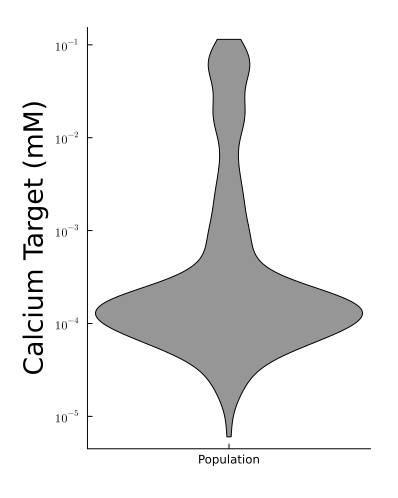

In [9]:
# 1. Calcule le log10 des cibles 
log_data = log10.(Ca_tgt_moyen[Ca_tgt_moyen .> 0])

p_ca_tgt = violin(log_data, 
             label="", 
             color=myGray, 
             grid=false,
             xticks=([1,], ["Population",]),
             yticks=([-5, -4, -3, -2, -1, 0], 
                    [L"10^{-5}", L"10^{-4}", L"10^{-3}", L"10^{-2}", L"10^{-1}", L"1"]), size=(400, 500))

ylabel!("Calcium Target (mM)")

# **Blockade Simulations**

> **Protocol** : Each simulation runs for 300 s. The target 
> conductance is set to 1e-18 at t = 30 s (instantaneous 
> pharmacological blockade). The homeostatic controller then 
> adjusts remaining conductances to recover Ca_tgt.

# **L-type Calcium Channel Blockade (Cav1.3)**

In [9]:
# 3. Lancement de la population

Tfinal = 300000
tt = 0.0 : 0.2 : Tfinal
tspan  = (0.0, Tfinal)

window_size_s = 5.0       
padding_s = 0.2           
window_size_  = Int64(round(window_size_s * 1000 / 0.2)) 
padding_      = Int64(round(padding_s * 1000 / 0.2))
tt_moving_average_plot = range(window_size_s/2, Tfinal/1000 - window_size_s/2, length=length(moving_average(zeros(length(tt)), window_size_, padding_)))

tau_g = 0.5
t_Na = 3

ncells= 200
Tfinal = tspan[2]           

sample_indices = 2:5000:length(tt)
data_length = length(sample_indices)

gNa_matrix = zeros(ncells, data_length)
gCaL_matrix = zero(gNa_matrix)
gKd_matrix = zero(gNa_matrix)
gKA_matrix = zero(gNa_matrix)
gKERG_matrix = zero(gNa_matrix)
gKSK_matrix = zero(gNa_matrix)
gH_matrix = zero(gNa_matrix)
gLNS_matrix = zero(gNa_matrix)
gLCa_matrix = zero(gNa_matrix)
gNtype_matrix = zero(gNa_matrix)
gTtype_matrix = zero(gNa_matrix)

freqs_pre = zeros(ncells)
freqs_acute = zeros(ncells)
freqs_comp = zeros(ncells)

ca_pre_population = zeros(ncells)
ca_acute_population = zeros(ncells)
ca_comp_population = zeros(ncells)

win_pre   = (5000, 25000)    # Avant blocage (30s)
win_acute = (35000, 55000)   # Juste après le blocage
win_comp  = (250000, 295000) # À la fin (compensation)

Ca_ma_matrix = zeros(ncells, length(tt_moving_average_plot))

@showprogress "Computing Population..." for i = 1 : ncells
    gNa = g_all_init[i,1]
    gCaL = g_all_init[i,2]
    gKd = g_all_init[i,3]
    gKA = g_all_init[i,4]
    gKERG = g_all_init[i,5]
    gKSK = g_all_init[i,6]
    gH = g_all_init[i,7]
    gLNS = g_all_init[i,8]
    gLCa = g_all_init[i,9]
    gNtype = 0.2*(0.9 + 0.2 * rand())
    gTtype = gTtype_final[i]
    
    Ca_tgt = Ca_tgt_moyen[i]
    
    tCaL   = t_Na * gNa / max(1e-6,gCaL)
    tKd    = t_Na * gNa / max(1e-6,gKd)
    tKA    = t_Na * gNa / max(1e-6,gKA)
    tKERG  = t_Na * gNa / max(1e-6,gKERG) 
    tKSK   = t_Na * gNa / max(1e-6,gKSK)
    tH     = t_Na * gNa / max(1e-6,gH)
    tLNS   = t_Na * gNa / max(1e-6,gLNS)
    tLCa   = t_Na * gNa / max(1e-6,gLCa)
    tNCa   = t_Na * gNa / max(1e-6,gNtype)
    tTCA   = t_Na * gNa / max(1e-6,gTtype)

    Iapp_val(t) = 0.0
    
    g_main_init = [gNa, gCaL, gKd, gKA, gKERG, gKSK, gH, gLNS, gLCa]
    m_main_init = copy(g_main_init) 
    
    g_cal = [gNtype, gTtype]
    m_cal = copy(g_cal)
    
    g_max = g_main_init*10
    g_max_TN = g_cal*10
    
    g_max_all = (g_max, g_max_TN)

    p_homeo = (Iapp_val, Ca_tgt, tau_g, t_Na, tCaL, tKd, tKA, tKERG, tKSK
        , tH, tLNS, tLCa, tNCa, tTCA, g_max_all)

    V0 = 0.0
    Ca0 = 1e-4
    
    u_biophys = [
        V0, m_inf(V0), h_inf(V0), hs_inf(V0), l_inf(V0), n_inf(V0), 
        p_inf(V0), q1_inf(V0), q2_inf(V0), 0.0, 0.0, mH_inf(V0), Ca0
    ]

    u_phys = [mN_inf(V0), hN_inf(V0), mT_inf(V0), hT_inf(V0)]

    u0_homeo = vcat(u_biophys, g_main_init, m_main_init, g_cal, m_cal, u_phys)

    prob = ODEProblem(DA_homeo_2014_ODE_Ntype_Ttype_Ltypeblock_LeakC, u0_homeo, tspan, p_homeo)
    
    sol_rigorous = solve(prob, Rodas5P(), reltol=1e-4, maxiters=1e7)
    
    if sol_rigorous.t[end] < Tfinal
        @warn "Crash persistant à t = $(sol_rigorous.t[end])"
    end
        
    t_echantillon = tt[sample_indices]
    temp_sol = sol_rigorous(t_echantillon)
    
    gNa_matrix[i, :]   = temp_sol[14, :]
    gCaL_regulee = temp_sol[15, :]
    gCaL_matrix[i, :] = [ (t_echantillon[j] < 30000.0) ? gCaL_regulee[j] : 1e-18 for j in 1:length(t_echantillon) ]
    gKd_matrix[i, :]   = temp_sol[16, :]
    gKA_matrix[i, :]   = temp_sol[17, :]
    gKERG_matrix[i, :] = temp_sol[18, :]
    gKSK_matrix[i, :]  = temp_sol[19, :]
    gH_matrix[i, :]    = temp_sol[20, :]
    gLNS_matrix[i, :]  = temp_sol[21, :]
    gLCa_matrix[i, :]  = temp_sol[22, :]
    
    gNtype_matrix[i, :] = temp_sol[32, :]
    gTtype_matrix[i, :] = temp_sol[33, :]
    Ca_ma_matrix[i, :] = moving_average(sol_rigorous(tt)[13, :], window_size_, padding_)
    
    # Extraction et calculs
    t_pre = win_pre[1]:0.1:win_pre[2]  
    sol_pre = sol_rigorous(t_pre)      
    f_pre = extract_frequency(sol_pre[1, :], t_pre)
    freqs_pre[i] = isnan(f_pre) ? 0.0 : f_pre 
    ca_pre_population[i] = mean(sol_pre[13, :]) 

    t_acute = win_acute[1]:0.1:win_acute[2]
    sol_acute = sol_rigorous(t_acute)
    f_acute = extract_frequency(sol_acute[1, :], t_acute)
    freqs_acute[i] = isnan(f_acute) ? 0.0 : f_acute
    ca_acute_population[i] = mean(sol_acute[13, :]) 

    t_comp = win_comp[1]:0.1:win_comp[2]
    sol_comp = sol_rigorous(t_comp)
    f_comp = extract_frequency(sol_comp[1, :], t_comp)
    freqs_comp[i] = isnan(f_comp) ? 0.0 : f_comp
    ca_comp_population[i] = mean(sol_comp[13, :]) 
end
        


Computing Population...   1%|█                           |  ETA: 1:02:58┌ Warning: Crash persistant à t = 6043.855393466742
└ @ Main In[9]:120
Computing Population...   2%|█                           |  ETA: 1:06:16┌ Warning: Crash persistant à t = 114646.09467069949
└ @ Main In[9]:120
Computing Population...  14%|█████                       |  ETA: 1:20:47┌ Warning: Crash persistant à t = 278027.91804717423
└ @ Main In[9]:120
Computing Population...  29%|█████████                   |  ETA: 1:05:45┌ Warning: Crash persistant à t = 4476.654036282811
└ @ Main In[9]:120
Computing Population...  30%|█████████                   |  ETA: 1:02:51┌ Warning: Crash persistant à t = 58242.49492657029
└ @ Main In[9]:120
Computing Population...  39%|███████████                 |  ETA: 0:57:06┌ Warning: Crash persistant à t = 112599.9043710635
└ @ Main In[9]:120
Computing Population...  44%|█████████████               |  ETA: 0:50:56┌ Warning: Crash persistant à t = 4723.100655622341
└ @ Main In[9]:1

LoadError: ParseError:
[90m# Error @ [0;0m]8;;file://C:/Users/elisa/OneDrive - Universite de Liege/Documents/Ingé civil/MASTER 2/TFE/population_2014/In[9]#163:1\[90mIn[9]:163:1[0;0m]8;;\

[48;2;120;70;70mend[0;0m
[90m└─┘ ── [0;0m[91minvalid identifier[0;0m

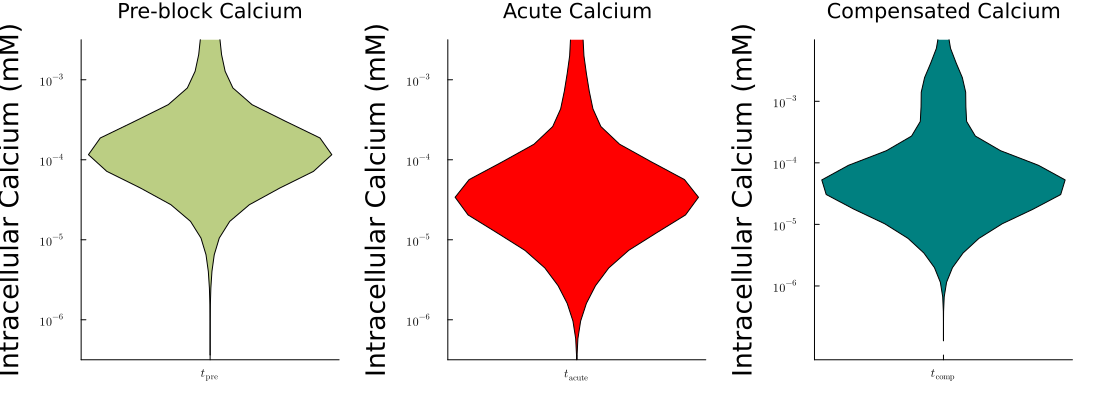

In [19]:
# Filtre les 3 neurones crashés
valid = (ca_pre_population .> 0) .& 
        (ca_acute_population .> 0) .& 
        (ca_comp_population .> 0)

log_ca_pre   = log10.(ca_pre_population[valid])
log_ca_acute = log10.(ca_acute_population[valid])
log_ca_comp  = log10.(ca_comp_population[valid])

y_ticks_val = [-6, -5, -4, -3]
y_ticks_lab = [L"10^{-6}", L"10^{-5}", L"10^{-4}", L"10^{-3}"]

# bandwidth=0.3 → c'est LE paramètre qui adoucit les bords
vc1 = violin([log_ca_pre], label="", color=myApple, grid=false, 
             title="Pre-block Calcium", npoints=800, bandwidth=0.3,trim= false,
             xticks=([1,], [L"t_\mathrm{pre}",]), 
             yticks=(y_ticks_val, y_ticks_lab), ylims=(-6.5, -2.5))

vc2 = violin([log_ca_acute], label="", color=:red, grid=false, 
             title="Acute Calcium", npoints=800, bandwidth=0.3,trim= false,
             xticks=([1,], [L"t_\mathrm{acute}",]), 
             yticks=(y_ticks_val, y_ticks_lab), ylims=(-6.5, -2.5))

vc3 = violin([log_ca_comp], label="", color=myTeal, grid=false, 
             title="Compensated Calcium", npoints=800, bandwidth=0.3,trim= false,
             xticks=([1,], [L"t_\mathrm{comp}",]), 
             yticks=(y_ticks_val, y_ticks_lab),ylims=(-7.2, -2.0))

p_calcium = plot(vc1, vc2, vc3, layout=(1,3), size=(1100, 400), 
                 ylabel="Intracellular Calcium (mM)",
                 link=:y)
display(p_calcium)

Résultats de la population (200 neurones) :
- Avant blocage : 71.5 % sont des pacemakers valides (0.5-15 Hz)
- Juste après blocage : 34.5 % sont des pacemakers valides
- Après compensation : 31.5 % sont des pacemakers valides


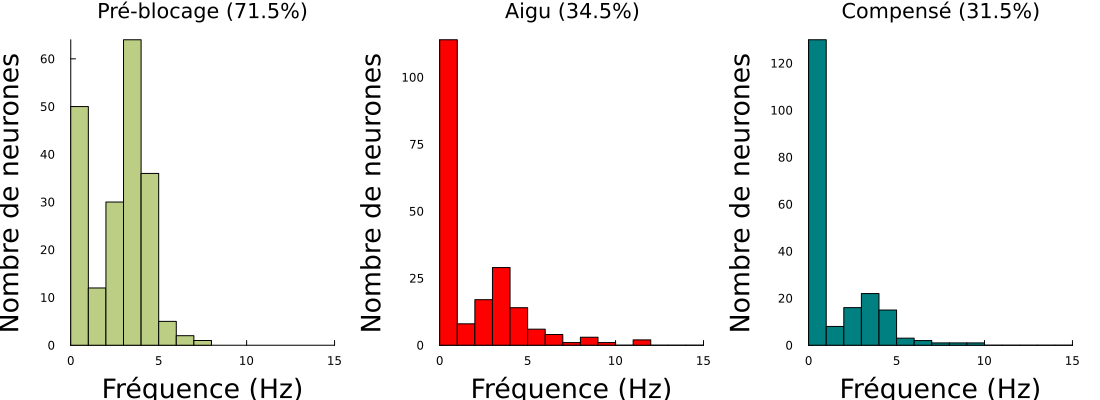

In [14]:
# --- 1. PARAMÈTRES DE FILTRAGE ---
seuil_bas = 0.5  # Seuil minimal (pacemaking)
seuil_haut = 5.0 # Seuil maximal (rejet des cas non-physiologiques)
myTeal = RGBA(0/255, 128/255, 128/255, 1)

n_simulated = length(freqs_pre) 

# Fonction utilitaire pour compter les pacemakers valides
is_valid_pm(f) = seuil_bas < f <= seuil_haut

# --- 2. CALCUL DES POURCENTAGES ---
pc_pre   = count(is_valid_pm, freqs_pre) / n_simulated * 100
pc_acute = count(is_valid_pm, freqs_acute) / n_simulated * 100
pc_comp  = count(is_valid_pm, freqs_comp) / n_simulated * 100

println("Résultats de la population ($n_simulated neurones) :")
println("- Avant blocage : $pc_pre % sont des pacemakers valides (0.5-15 Hz)")
println("- Juste après blocage : $pc_acute % sont des pacemakers valides")
println("- Après compensation : $pc_comp % sont des pacemakers valides")

# --- 3. LES GRAPHIQUES ---
# On ajoute xlims pour bien visualiser la coupure à 15Hz
h1 = histogram(freqs_pre, title="Pré-blocage ($pc_pre%)", color=myApple, label="", xlims=(0, 15))
h2 = histogram(freqs_acute, title="Aigu ($pc_acute%)", color=:red, label="", xlims=(0, 15))
h3 = histogram(freqs_comp, title="Compensé ($pc_comp%)", color=myTeal, label="", xlims=(0, 15))



plot(h1, h2, h3, layout=(1,3), size=(1100, 400), xlabel="Fréquence (Hz)", ylabel="Nombre de neurones")

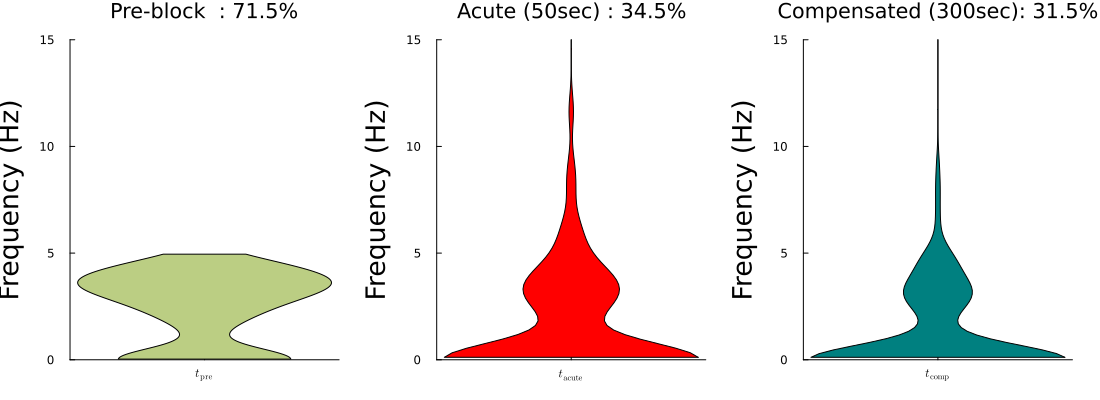

In [22]:
# --- 1. FILTRAGE DE FREQS_PRE ---
# On ne garde que les neurones qui spikent à moins de 5 Hz en condition initiale
freqs_pre_filtered = freqs_pre[freqs_pre .<= 5.0]

# --- 2. CALCUL DES POURCENTAGES (basé sur le total initial) ---
n_total = length(freqs_pre)
pc_pre   = count(f -> 0.5 < f <= 5.0, freqs_pre) / n_total * 100
pc_acute = count(is_valid_pm, freqs_acute) / n_total * 100
pc_comp  = count(is_valid_pm, freqs_comp) / n_total * 100

# --- 3. LES VIOLIN PLOTS ---
# Note : on utilise freqs_pre_filtered uniquement pour le premier plot
v1 = violin([freqs_pre_filtered], label="", color=myApple, grid=false,
            title="Pre-block  : $pc_pre%",
            xticks=([1,], [L"t_\mathrm{pre}",]), ylims=(0, 15))

v2 = violin([freqs_acute], label="", color=:red, grid=false,
            title="Acute (50sec) : $pc_acute%",
            xticks=([1,], [L"t_\mathrm{acute}",]), ylims=(0, 15))

v3 = violin([freqs_comp], label="", color=myTeal, grid=false,
            title="Compensated (300sec): $pc_comp%",
            xticks=([1,], [L"t_\mathrm{comp}",]), ylims=(0, 15))

plot(v1, v2, v3, layout=(1,3), size=(1100, 400), ylabel="Frequency (Hz)")

# **A-type Potassium Channel Blockade — Model Validation**

In [23]:
# 3. Lancement de la population
Tfinal = 300000
tt = 0.0 : 0.2 : Tfinal
tspan  = (0.0, Tfinal)

window_size_s = 5.0       
padding_s = 0.2           
window_size_  = Int64(round(window_size_s * 1000 / 0.2)) 
padding_      = Int64(round(padding_s * 1000 / 0.2))
tt_moving_average_plot = range(window_size_s/2, Tfinal/1000 - window_size_s/2, length=length(moving_average(zeros(length(tt)), window_size_, padding_)))

tau_g = 0.5
t_Na = 3

ncells= 200
Tfinal = tspan[2]           

sample_indices = 2:5000:length(tt)
data_length = length(sample_indices)

gNa_matrix = zeros(ncells, data_length)
gCaL_matrix = zero(gNa_matrix)
gKd_matrix = zero(gNa_matrix)
gKA_matrix = zero(gNa_matrix)
gKERG_matrix = zero(gNa_matrix)
gKSK_matrix = zero(gNa_matrix)
gH_matrix = zero(gNa_matrix)
gLNS_matrix = zero(gNa_matrix)
gLCa_matrix = zero(gNa_matrix)
gNtype_matrix = zero(gNa_matrix)
gTtype_matrix = zero(gNa_matrix)

freqs_pre = zeros(ncells)
freqs_acute = zeros(ncells)
freqs_comp = zeros(ncells)

win_pre   = (5000, 25000)    
win_acute = (35000, 55000)   
win_comp  = (250000, 295000) 

Ca_ma_matrix = zeros(ncells, length(tt_moving_average_plot))

@showprogress "Computing Population..." for i = 1 : ncells
    gNa = g_all_init[i,1]
    gCaL = g_all_init[i,2]
    gKd = g_all_init[i,3]
    gKA = g_all_init[i,4]
    gKERG = g_all_init[i,5]
    gKSK = g_all_init[i,6]
    gH = g_all_init[i,7]
    gLNS = g_all_init[i,8]
    gLCa = g_all_init[i,9]
    gNtype = 0.2*(0.9 + 0.2 * rand())
    gTtype = gTtype_final[i]
    
    Ca_tgt = Ca_tgt_moyen[i]
    
    tCaL   = t_Na * gNa / max(1e-6,gCaL)
    tKd    = t_Na * gNa / max(1e-6,gKd)
    tKA    = t_Na * gNa / max(1e-6,gKA)
    tKERG  = t_Na * gNa / max(1e-6,gKERG) 
    tKSK   = t_Na * gNa / max(1e-6,gKSK)
    tH     = t_Na * gNa / max(1e-6,gH)
    tLNS   = t_Na * gNa / max(1e-6,gLNS)
    tLCa   = t_Na * gNa / max(1e-6,gLCa)
    tNCa   = t_Na * gNa / max(1e-6,gNtype)
    tTCA   = t_Na * gNa / max(1e-6,gTtype)
    
    Iapp_val(t) = 0.0
    
    g_main_init = [gNa, gCaL, gKd, gKA, gKERG, gKSK, gH, gLNS, gLCa]
    m_main_init = copy(g_main_init) 
    
    g_cal = [gNtype, gTtype]
    m_cal = copy(g_cal)
    
    g_max = g_main_init*10
    g_max_TN = g_cal*10
    
    g_max_all = (g_max, g_max_TN)

    p_homeo = (Iapp_val, Ca_tgt, tau_g, t_Na, tCaL, tKd, tKA, tKERG, tKSK
        , tH, tLNS, tLCa, tNCa, tTCA, g_max_all)

    V0 = 0.0
    Ca0 = 1e-4
    
    u_biophys = [
        V0, m_inf(V0), h_inf(V0), hs_inf(V0), l_inf(V0), n_inf(V0), 
        p_inf(V0), q1_inf(V0), q2_inf(V0), 0.0, 0.0, mH_inf(V0), Ca0]

    u_phys = [mN_inf(V0), hN_inf(V0), mT_inf(V0), hT_inf(V0)]

    u0_homeo = vcat(u_biophys, g_main_init, m_main_init, g_cal, m_cal, u_phys)

    prob = ODEProblem(DA_homeo_2014_AType, u0_homeo, tspan, p_homeo)
    
    sol_rigorous = solve(prob, Rodas5P(), reltol=1e-4, maxiters=1e7)
    
    if sol_rigorous.t[end] < Tfinal
        @warn "Crash persistant à t = $(sol_rigorous.t[end])"
    end
        
    t_echantillon = tt[sample_indices]
    temp_sol = sol_rigorous(t_echantillon)
    
    gNa_matrix[i, :]   = temp_sol[14, :]
    gCaL_matrix[i, :]  = temp_sol[15, :]
    gKd_matrix[i, :]   = temp_sol[16, :]
    gKA_regulee = temp_sol[17, :]
    gKA_matrix[i,:] = [ (t_echantillon[j] < 30000.0) ? gKA_regulee[j] : 1e-18 for j in 1:length(t_echantillon) ]
    gKERG_matrix[i, :] = temp_sol[18, :]
    gKSK_matrix[i, :]  = temp_sol[19, :]
    gH_matrix[i, :]    = temp_sol[20, :]
    gLNS_matrix[i, :]  = temp_sol[21, :]
    gLCa_matrix[i, :]  = temp_sol[22, :]
    
    gNtype_matrix[i, :] = temp_sol[32, :]
    gTtype_matrix[i, :] = temp_sol[33, :]
    Ca_ma_matrix[i, :] = moving_average(sol_rigorous(tt)[13, :], window_size_, padding_)
    
    # 1. Analyse AVANT BLOCAGE
    t_pre = win_pre[1]:0.1:win_pre[2]  
    sol_pre = sol_rigorous(t_pre)      
    f_pre = extract_frequency(sol_pre[1, :], t_pre)
    freqs_pre[i] = isnan(f_pre) ? 0.0 : f_pre 

    # 2. Analyse AIGU 
    t_acute = win_acute[1]:0.1:win_acute[2]
    sol_acute = sol_rigorous(t_acute)
    f_acute = extract_frequency(sol_acute[1, :], t_acute)
    freqs_acute[i] = isnan(f_acute) ? 0.0 : f_acute

    # 3. Analyse COMPENSÉ 
    t_comp = win_comp[1]:0.1:win_comp[2]
    sol_comp = sol_rigorous(t_comp)
    f_comp = extract_frequency(sol_comp[1, :], t_comp)
    freqs_comp[i] = isnan(f_comp) ? 0.0 : f_comp
        

end

Computing Population...   1%|█                           |  ETA: 5:09:15┌ Warning: Crash persistant à t = 261074.76111520652
└ @ Main In[23]:116
Computing Population...   2%|█                           |  ETA: 6:14:17┌ Warning: Crash persistant à t = 50655.4930618838
└ @ Main In[23]:116
Computing Population...   9%|███                         |  ETA: 6:30:25┌ Warning: Crash persistant à t = 54784.55523401892
└ @ Main In[23]:116
Computing Population...  10%|███                         |  ETA: 6:01:05┌ Warning: Crash persistant à t = 42470.63518777784
└ @ Main In[23]:116
Computing Population...  16%|█████                       |  ETA: 4:36:02┌ Warning: Crash persistant à t = 49893.19277847295
└ @ Main In[23]:116
Computing Population...  18%|█████                       |  ETA: 4:17:10┌ Warning: Crash persistant à t = 60267.636000644234
└ @ Main In[23]:116
Computing Population...  26%|████████                    |  ETA: 3:22:34┌ Warning: Crash persistant à t = 57337.44103825136
└ @ Main In

Résultats de la population (200 neurones) :
- Avant blocage : 71.5 % sont des pacemakers valides (0.5-15 Hz)
- Juste après blocage : 44.5 % sont des pacemakers valides
- Après compensation : 35.0 % sont des pacemakers valides


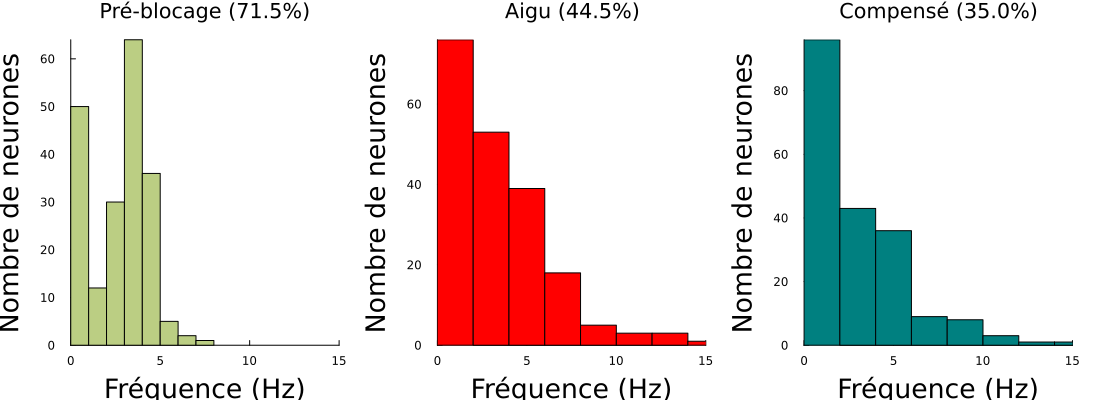

In [24]:
# --- 1. PARAMÈTRES DE FILTRAGE ---
seuil_bas = 0.5  # Seuil minimal (pacemaking)
seuil_haut = 5.0 # Seuil maximal (rejet des cas non-physiologiques)
myTeal = RGBA(0/255, 128/255, 128/255, 1)

n_simulated = length(freqs_pre) 

# Fonction utilitaire pour compter les pacemakers valides
is_valid_pm(f) = seuil_bas < f <= seuil_haut

# --- 2. CALCUL DES POURCENTAGES ---
pc_pre   = count(is_valid_pm, freqs_pre) / n_simulated * 100
pc_acute = count(is_valid_pm, freqs_acute) / n_simulated * 100
pc_comp  = count(is_valid_pm, freqs_comp) / n_simulated * 100

println("Résultats de la population ($n_simulated neurones) :")
println("- Avant blocage : $pc_pre % sont des pacemakers valides (0.5-15 Hz)")
println("- Juste après blocage : $pc_acute % sont des pacemakers valides")
println("- Après compensation : $pc_comp % sont des pacemakers valides")

# --- 3. LES GRAPHIQUES ---
# On ajoute xlims pour bien visualiser la coupure à 15Hz
h1 = histogram(freqs_pre, title="Pré-blocage ($pc_pre%)", color=myApple, label="", xlims=(0, 15))
h2 = histogram(freqs_acute, title="Aigu ($pc_acute%)", color=:red, label="", xlims=(0, 15))
h3 = histogram(freqs_comp, title="Compensé ($pc_comp%)", color=myTeal, label="", xlims=(0, 15))



plot(h1, h2, h3, layout=(1,3), size=(1100, 400), xlabel="Fréquence (Hz)", ylabel="Nombre de neurones")

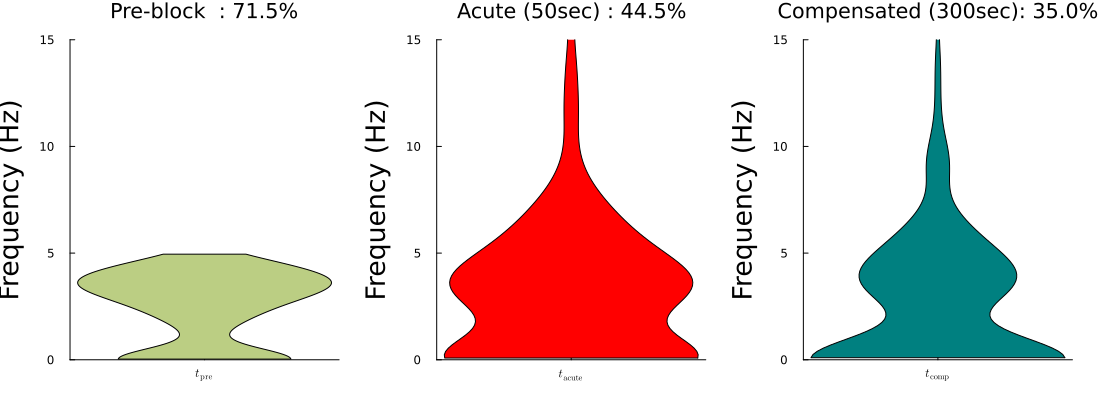

In [25]:
# --- 1. FILTRAGE DE FREQS_PRE ---
# On ne garde que les neurones qui spikent à moins de 5 Hz en condition initiale
freqs_pre_filtered = freqs_pre[freqs_pre .<= 5.0]

# --- 2. CALCUL DES POURCENTAGES (basé sur le total initial) ---
n_total = length(freqs_pre)
pc_pre   = count(f -> 0.5 < f <= 5.0, freqs_pre) / n_total * 100
pc_acute = count(is_valid_pm, freqs_acute) / n_total * 100
pc_comp  = count(is_valid_pm, freqs_comp) / n_total * 100

# --- 3. LES VIOLIN PLOTS ---
# Note : on utilise freqs_pre_filtered uniquement pour le premier plot
v1 = violin([freqs_pre_filtered], label="", color=myApple, grid=false,
            title="Pre-block  : $pc_pre%",
            xticks=([1,], [L"t_\mathrm{pre}",]), ylims=(0, 15))

v2 = violin([freqs_acute], label="", color=:red, grid=false,
            title="Acute (50sec) : $pc_acute%",
            xticks=([1,], [L"t_\mathrm{acute}",]), ylims=(0, 15))

v3 = violin([freqs_comp], label="", color=myTeal, grid=false,
            title="Compensated (300sec): $pc_comp%",
            xticks=([1,], [L"t_\mathrm{comp}",]), ylims=(0, 15))

plot(v1, v2, v3, layout=(1,3), size=(1100, 400), ylabel="Frequency (Hz)")

# **HCN Channel Blockade — Model Validation**

In [26]:
# 3. Lancement de la population

Tfinal = 300000
tt = 0.0 : 0.2 : Tfinal
tspan  = (0.0, Tfinal)

window_size_s = 5.0       
padding_s = 0.2           
window_size_  = Int64(round(window_size_s * 1000 / 0.2)) 
padding_      = Int64(round(padding_s * 1000 / 0.2))
tt_moving_average_plot = range(window_size_s/2, Tfinal/1000 - window_size_s/2, length=length(moving_average(zeros(length(tt)), window_size_, padding_)))

tau_g = 0.5
t_Na = 3

ncells= 200
Tfinal = tspan[2]           

sample_indices = 2:5000:length(tt)
data_length = length(sample_indices)

gNa_matrix = zeros(ncells, data_length)
gCaL_matrix = zero(gNa_matrix)
gKd_matrix = zero(gNa_matrix)
gKA_matrix = zero(gNa_matrix)
gKERG_matrix = zero(gNa_matrix)
gKSK_matrix = zero(gNa_matrix)
gH_matrix = zero(gNa_matrix)
gLNS_matrix = zero(gNa_matrix)
gLCa_matrix = zero(gNa_matrix)
gNtype_matrix = zero(gNa_matrix)
gTtype_matrix = zero(gNa_matrix)

freqs_pre = zeros(ncells)
freqs_acute = zeros(ncells)
freqs_comp = zeros(ncells)

win_pre   = (5000, 25000)   
win_acute = (35000, 55000)   
win_comp  = (250000, 295000) 

Ca_ma_matrix = zeros(ncells, length(tt_moving_average_plot))

@showprogress "Computing Population..." for i = 1 : ncells
    gNa = g_all_init[i,1]
    gCaL = g_all_init[i,2]
    gKd = g_all_init[i,3]
    gKA = g_all_init[i,4]
    gKERG = g_all_init[i,5]
    gKSK = g_all_init[i,6]
    gH = g_all_init[i,7]
    gLNS = g_all_init[i,8]
    gLCa = g_all_init[i,9]
    gNtype = 0.2*(0.9 + 0.2 * rand())
    gTtype = gTtype_final[i]

    Ca_tgt = Ca_tgt_moyen[i]
    
    tCaL   = t_Na * gNa / max(1e-6,gCaL)
    tKd    = t_Na * gNa / max(1e-6,gKd)
    tKA    = t_Na * gNa / max(1e-6,gKA)
    tKERG  = t_Na * gNa / max(1e-6,gKERG) 
    tKSK   = t_Na * gNa / max(1e-6,gKSK)
    tH     = t_Na * gNa / max(1e-6,gH)
    tLNS   = t_Na * gNa / max(1e-6,gLNS)
    tLCa   = t_Na * gNa / max(1e-6,gLCa)
    tNCa   = t_Na * gNa / max(1e-6,gNtype)
    tTCA   = t_Na * gNa / max(1e-6,gTtype)
    
    Iapp_val(t) = 0.0

    g_main_init = [gNa, gCaL, gKd, gKA, gKERG, gKSK, gH, gLNS, gLCa]
    m_main_init = copy(g_main_init) 
    
    g_cal = [gNtype, gTtype]
    m_cal = copy(g_cal)
    
    g_max = g_main_init*10
    g_max_TN = g_cal*10
    
    g_max_all = (g_max, g_max_TN)

    p_homeo = (Iapp_val, Ca_tgt, tau_g, t_Na, tCaL, tKd, tKA, tKERG, tKSK
        , tH, tLNS, tLCa, tNCa, tTCA, g_max_all)

    V0 = 0.0
    Ca0 = 1e-4
    
    u_biophys = [
        V0, m_inf(V0), h_inf(V0), hs_inf(V0), l_inf(V0), n_inf(V0), 
        p_inf(V0), q1_inf(V0), q2_inf(V0), 0.0, 0.0, mH_inf(V0), Ca0]

    u_phys = [mN_inf(V0), hN_inf(V0), mT_inf(V0), hT_inf(V0)]

    u0_homeo = vcat(u_biophys, g_main_init, m_main_init, g_cal, m_cal, u_phys)

    prob = ODEProblem(DA_homeo_2014_HType, u0_homeo, tspan, p_homeo)
    
    sol_rigorous = solve(prob, Rodas5P(), reltol=1e-4, maxiters=1e7)
    
    if sol_rigorous.t[end] < Tfinal
        @warn "Crash persistant à t = $(sol_rigorous.t[end])"
    end
        
    t_echantillon = tt[sample_indices]
    temp_sol = sol_rigorous(t_echantillon)
    
    gNa_matrix[i, :]   = temp_sol[14, :]
    gCaL_matrix[i, :]  = temp_sol[15, :]
    gKd_matrix[i, :]   = temp_sol[16, :]
    gKA_matrix[i, :]   = temp_sol[17, :]
    gKERG_matrix[i, :] = temp_sol[18, :]
    gKSK_matrix[i, :]  = temp_sol[19, :]
    gH_regulee = temp_sol[20, :]
    gH_matrix[i,:] = [ (t_echantillon[j] < 30000.0) ? gH_regulee[j] : 1e-18 for j in 1:length(t_echantillon) ]
    gLNS_matrix[i, :]  = temp_sol[21, :]
    gLCa_matrix[i, :]  = temp_sol[22, :]
    
    gNtype_matrix[i, :] = temp_sol[32, :]
    gTtype_matrix[i, :] = temp_sol[33, :]
    Ca_ma_matrix[i, :] = moving_average(sol_rigorous(tt)[13, :], window_size_, padding_)
    
    # 1. Analyse AVANT BLOCAGE
    t_pre = win_pre[1]:0.1:win_pre[2]  
    sol_pre = sol_rigorous(t_pre)      
    f_pre = extract_frequency(sol_pre[1, :], t_pre)
    freqs_pre[i] = isnan(f_pre) ? 0.0 : f_pre 

    # 2. Analyse AIGU 
    t_acute = win_acute[1]:0.1:win_acute[2]
    sol_acute = sol_rigorous(t_acute)
    f_acute = extract_frequency(sol_acute[1, :], t_acute)
    freqs_acute[i] = isnan(f_acute) ? 0.0 : f_acute

    # 3. Analyse COMPENSÉ 
    t_comp = win_comp[1]:0.1:win_comp[2]
    sol_comp = sol_rigorous(t_comp)
    f_comp = extract_frequency(sol_comp[1, :], t_comp)
    freqs_comp[i] = isnan(f_comp) ? 0.0 : f_comp
        

end

Computing Population...   2%|█                           |  ETA: 1:49:51┌ Warning: Crash persistant à t = 65102.79622056037
└ @ Main In[26]:116
Computing Population...   9%|███                         |  ETA: 1:43:39┌ Warning: Crash persistant à t = 75017.91277822494
└ @ Main In[26]:116
Computing Population...  10%|███                         |  ETA: 1:42:01┌ Warning: Crash persistant à t = 46699.1007338386
└ @ Main In[26]:116
Computing Population...  16%|█████                       |  ETA: 1:43:20┌ Warning: Crash persistant à t = 73082.28400523205
└ @ Main In[26]:116
Computing Population...  18%|█████                       |  ETA: 1:41:13┌ Warning: Crash persistant à t = 114092.79339916697
└ @ Main In[26]:116
Computing Population...  28%|████████                    |  ETA: 1:25:29┌ Warning: Crash persistant à t = 47033.246604177104
└ @ Main In[26]:116
Computing Population...  29%|█████████                   |  ETA: 1:23:35┌ Warning: Crash persistant à t = 4649.87760155972
└ @ Main In[

Résultats de la population (200 neurones) :
- Avant blocage : 71.5 % sont des pacemakers valides (0.5-15 Hz)
- Juste après blocage : 63.5 % sont des pacemakers valides
- Après compensation : 56.49999999999999 % sont des pacemakers valides


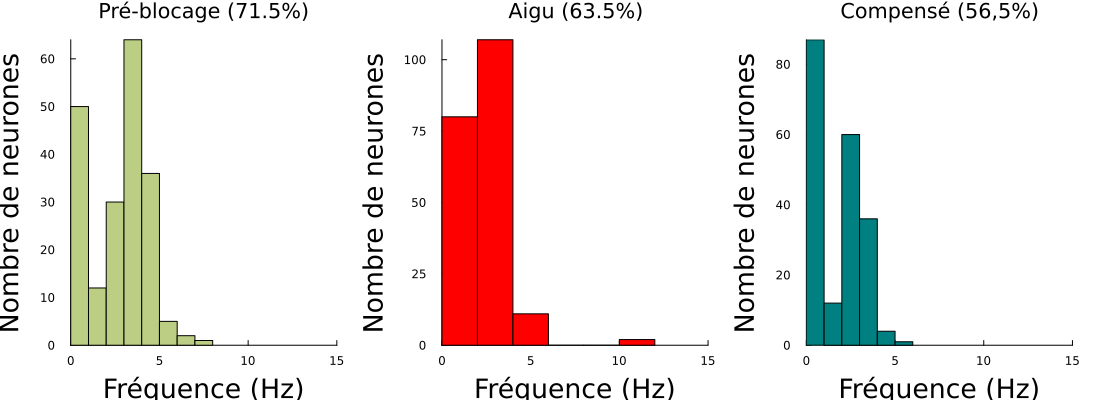

In [27]:
# --- 1. PARAMÈTRES DE FILTRAGE ---
seuil_bas = 0.5  # Seuil minimal (pacemaking)
seuil_haut = 5.0 # Seuil maximal (rejet des cas non-physiologiques)
myTeal = RGBA(0/255, 128/255, 128/255, 1)

n_simulated = length(freqs_pre) 

# Fonction utilitaire pour compter les pacemakers valides
is_valid_pm(f) = seuil_bas < f <= seuil_haut

# --- 2. CALCUL DES POURCENTAGES ---
pc_pre   = count(is_valid_pm, freqs_pre) / n_simulated * 100
pc_acute = count(is_valid_pm, freqs_acute) / n_simulated * 100
pc_comp  = count(is_valid_pm, freqs_comp) / n_simulated * 100

println("Résultats de la population ($n_simulated neurones) :")
println("- Avant blocage : $pc_pre % sont des pacemakers valides (0.5-15 Hz)")
println("- Juste après blocage : $pc_acute % sont des pacemakers valides")
println("- Après compensation : $pc_comp % sont des pacemakers valides")

# --- 3. LES GRAPHIQUES ---
# On ajoute xlims pour bien visualiser la coupure à 15Hz
h1 = histogram(freqs_pre, title="Pré-blocage ($pc_pre%)", color=myApple, label="", xlims=(0, 15))
h2 = histogram(freqs_acute, title="Aigu ($pc_acute%)", color=:red, label="", xlims=(0, 15))
h3 = histogram(freqs_comp, title="Compensé (56,5%)", color=myTeal, label="", xlims=(0, 15))



plot(h1, h2, h3, layout=(1,3), size=(1100, 400), xlabel="Fréquence (Hz)", ylabel="Nombre de neurones")

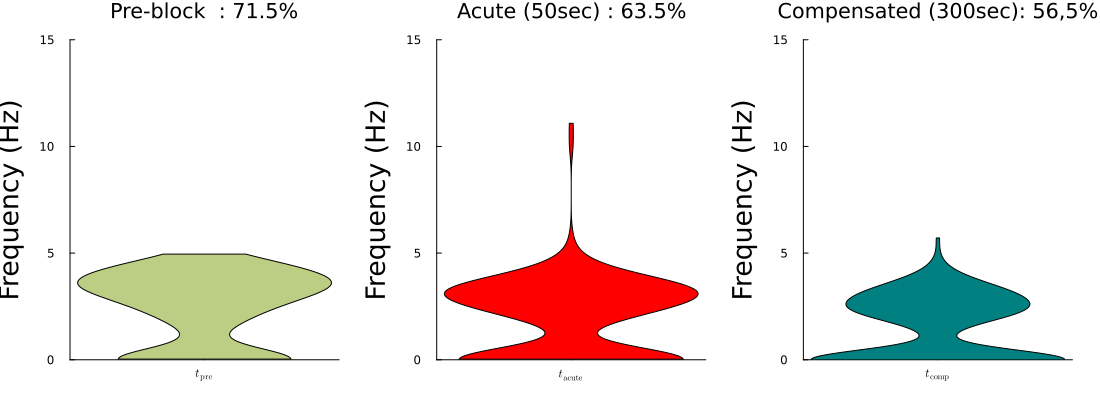

In [29]:
# --- 1. FILTRAGE DE FREQS_PRE ---
# On ne garde que les neurones qui spikent à moins de 5 Hz en condition initiale
freqs_pre_filtered = freqs_pre[freqs_pre .<= 5.0]

# --- 2. CALCUL DES POURCENTAGES (basé sur le total initial) ---
n_total = length(freqs_pre)
pc_pre   = count(f -> 0.5 < f <= 5.0, freqs_pre) / n_total * 100
pc_acute = count(is_valid_pm, freqs_acute) / n_total * 100
pc_comp  = count(is_valid_pm, freqs_comp) / n_total * 100

# --- 3. LES VIOLIN PLOTS ---
# Note : on utilise freqs_pre_filtered uniquement pour le premier plot
v1 = violin([freqs_pre_filtered], label="", color=myApple, grid=false,
            title="Pre-block  : $pc_pre%",
            xticks=([1,], [L"t_\mathrm{pre}",]), ylims=(0, 15))

v2 = violin([freqs_acute], label="", color=:red, grid=false,
            title="Acute (50sec) : $pc_acute%",
            xticks=([1,], [L"t_\mathrm{acute}",]), ylims=(0, 15))

v3 = violin([freqs_comp], label="", color=myTeal, grid=false,
            title="Compensated (300sec): 56,5%",
            xticks=([1,], [L"t_\mathrm{comp}",]), ylims=(0, 15))

plot(v1, v2, v3, layout=(1,3), size=(1100, 400), ylabel="Frequency (Hz)")